In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.99072, 6.00093] 
    logm2lim = [0.99586, 1.00034]
    alim = [0.68086, 0.70203]
    p0lim = [8.98819, 9.10957]
    e0lim = [0.39969, 0.40370]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.99072, 6.00093] 
    logm2lim = [0.99586, 1.00034]
    alim = [0.68086, 0.70203]
    p0lim = [8.98819, 9.10957]
    e0lim = [0.39969, 0.40370]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


print('Done setting up log-likelihood and prior.')

Using dt=5s, T=1.0yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
Done setting up log-likelihood and prior.


In [2]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris5_noise/int_1yr_dist'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list



In [4]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, exclude_scale_z=inf, use_pool=False, n_pool=10, stop_on_merge=False, merge_type='distance', cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [5]:
sampler.init_cov_list

[array([[1.e-05, 0.e+00, 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 1.e-05, 0.e+00, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 1.e-05, 0.e+00, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, 1.e-05, 0.e+00],
        [0.e+00, 0.e+00, 0.e+00, 0.e+00, 1.e-05]])]

In [6]:
proc_pt, logden_list

([array([[0.921525  , 0.89630093, 0.9240121 , 0.07704324, 0.09563724],
         [0.91969249, 0.89694244, 0.92663025, 0.08081143, 0.09567828],
         [0.92107487, 0.89302381, 0.9268597 , 0.07864526, 0.09249526],
         ...,
         [0.        , 0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ],
         [0.        , 0.        , 0.        , 0.        , 0.        ]])],
 [array([ 2.47602289e+01, -6.40361233e-03,  1.09250255e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00])])

In [7]:
sampler.now_covariances

[array([[ 0.00518337,  0.00408641,  0.00536959, -0.00535865, -0.00426886],
        [ 0.00408641,  0.00441427,  0.00404533, -0.00402129, -0.00422512],
        [ 0.00536959,  0.00404533,  0.0055926 , -0.00558336, -0.00428592],
        [-0.00535865, -0.00402129, -0.00558336,  0.00557458,  0.00426625],
        [-0.00426886, -0.00422512, -0.00428592,  0.00426625,  0.00413781]])]

In [8]:
np.argmax(logden_list)

4173

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00079056, 1.00019268, 0.70176562, 8.98989313, 0.39980155]])

In [10]:
log_density(maxld_pt1)

array([25.33197055])

In [11]:
log_density([param_true])

array([24.83302504])

In [12]:
param_ranges = [(5.99072, 6.00093),
                (0.99586, 1.00034),
                (0.68086, 0.70203),
                (8.98819, 9.10957),
                (0.39969, 0.40370),
                ]
param_ranges

[(5.99072, 6.00093),
 (0.99586, 1.00034),
 (0.68086, 0.70203),
 (8.98819, 9.10957),
 (0.39969, 0.4037)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

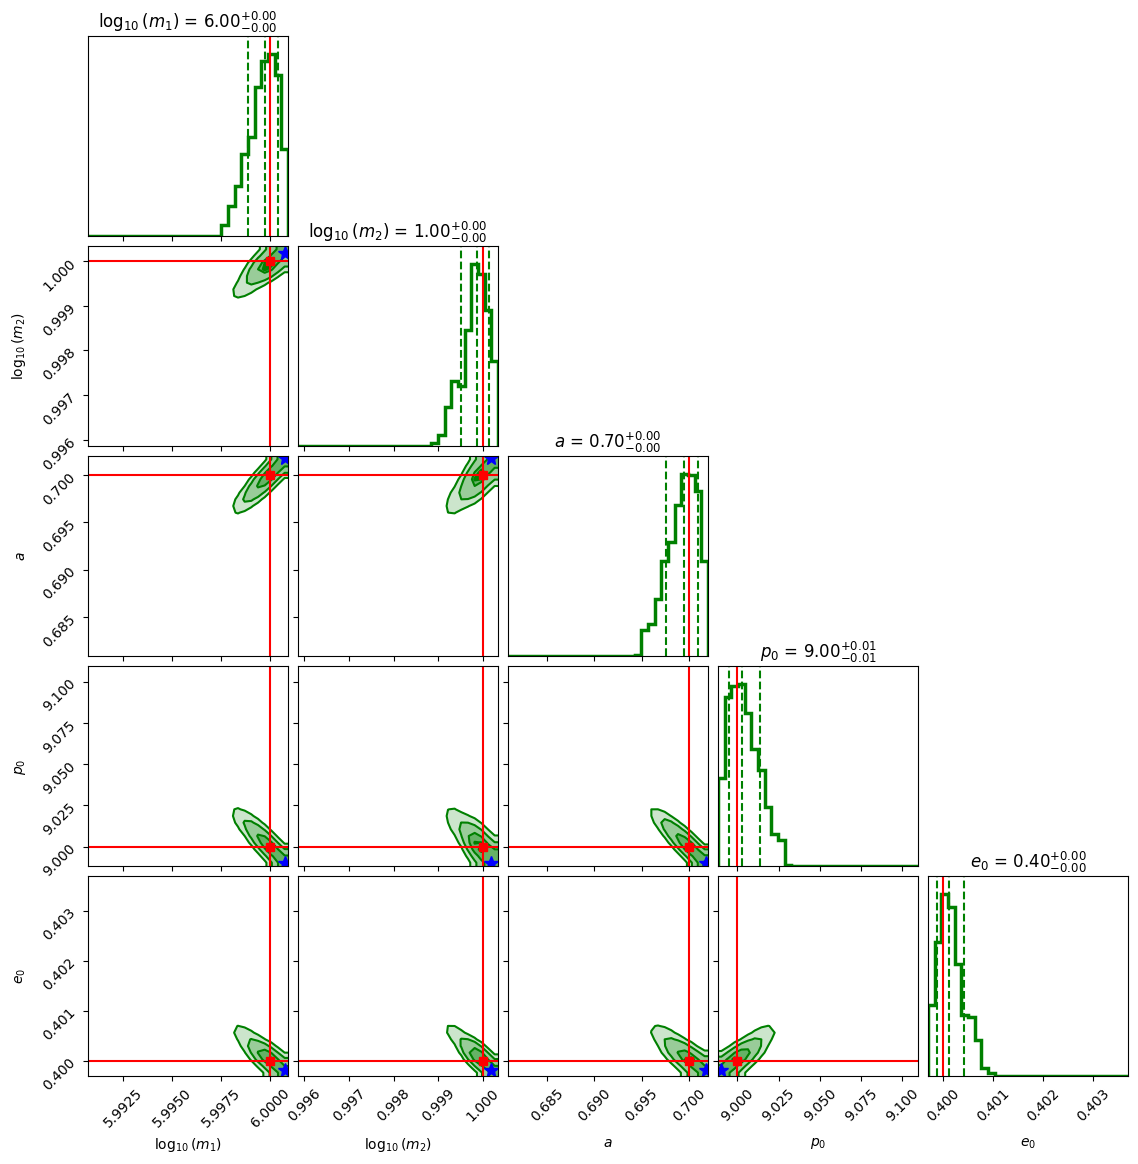

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




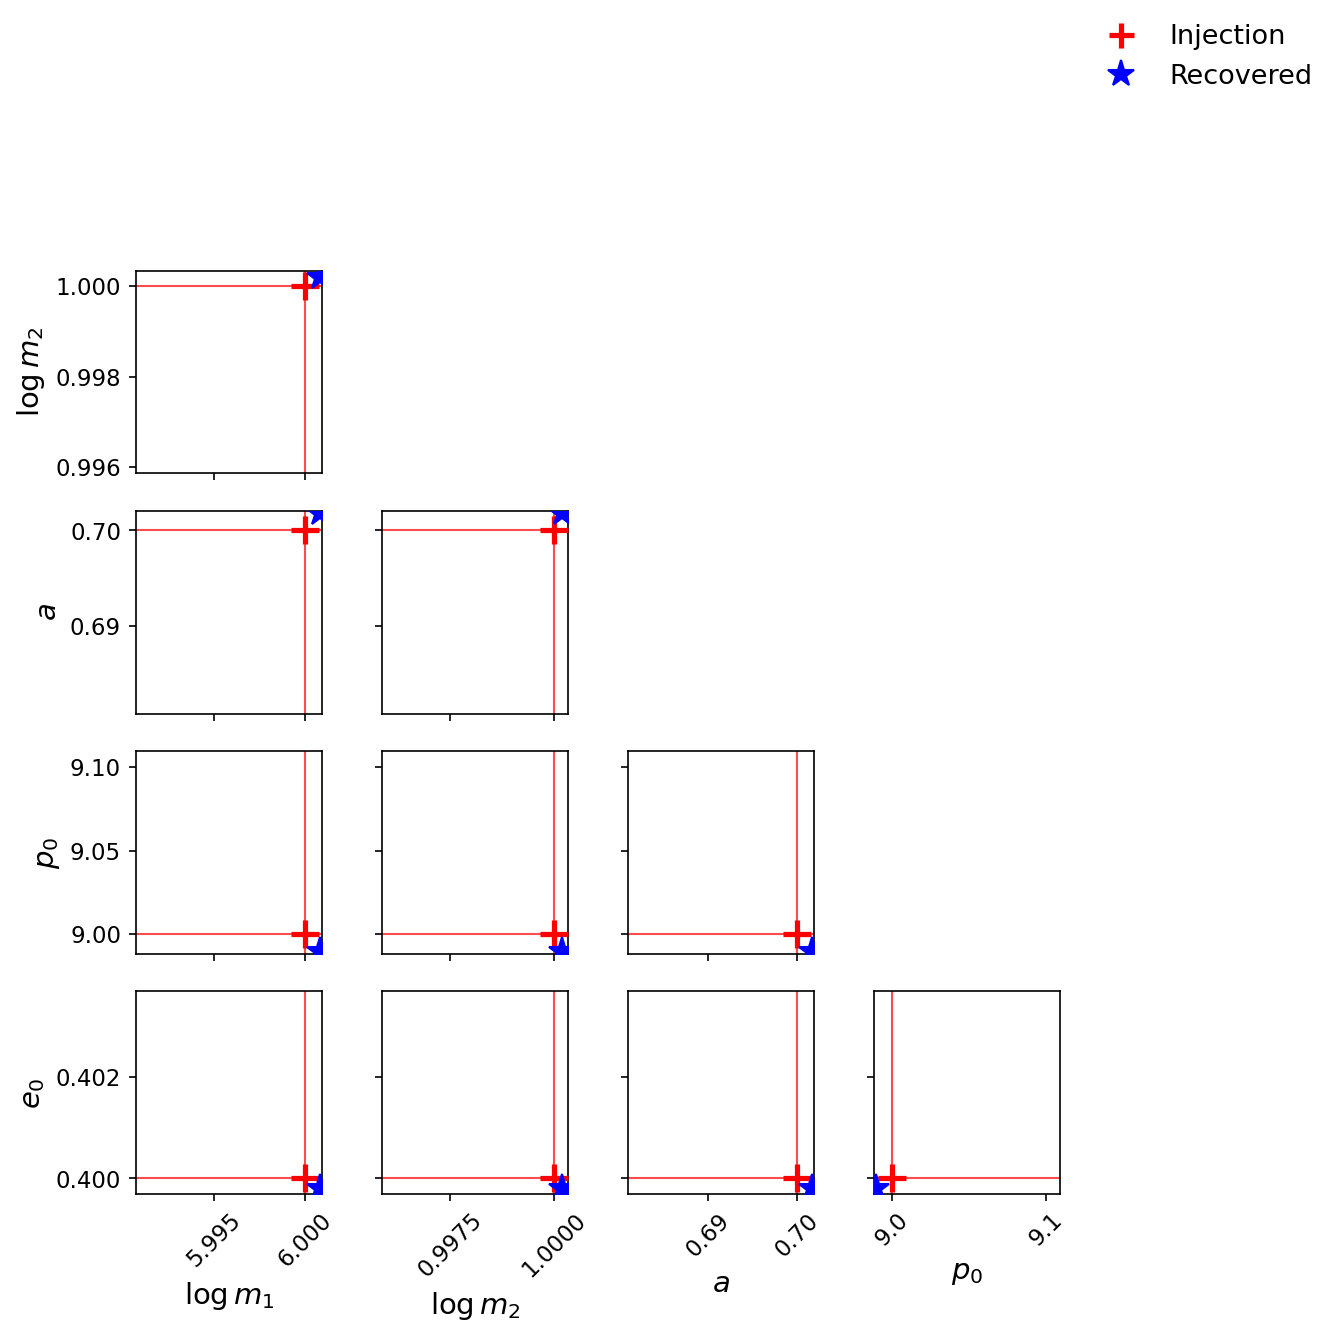

In [15]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(9, 9))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)

        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

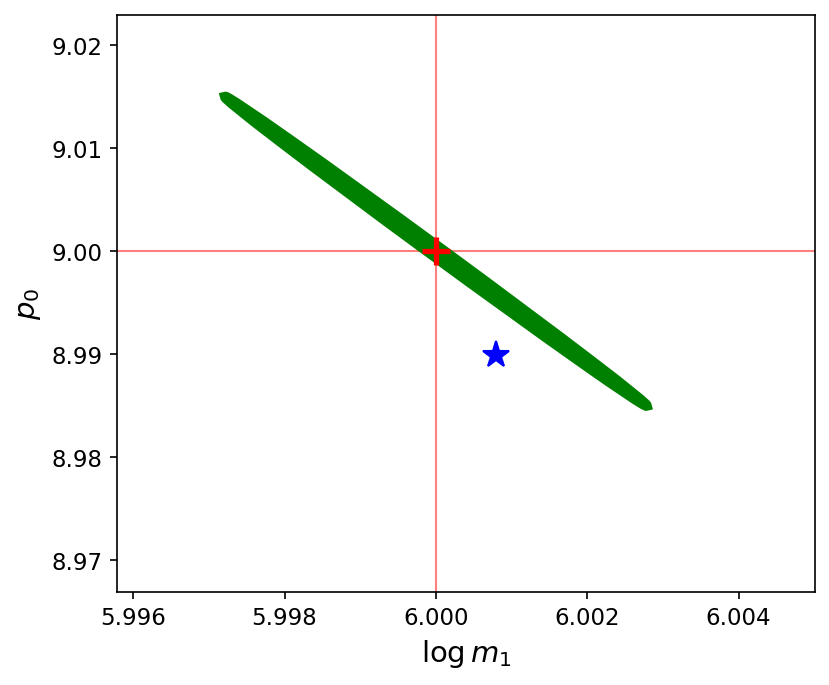

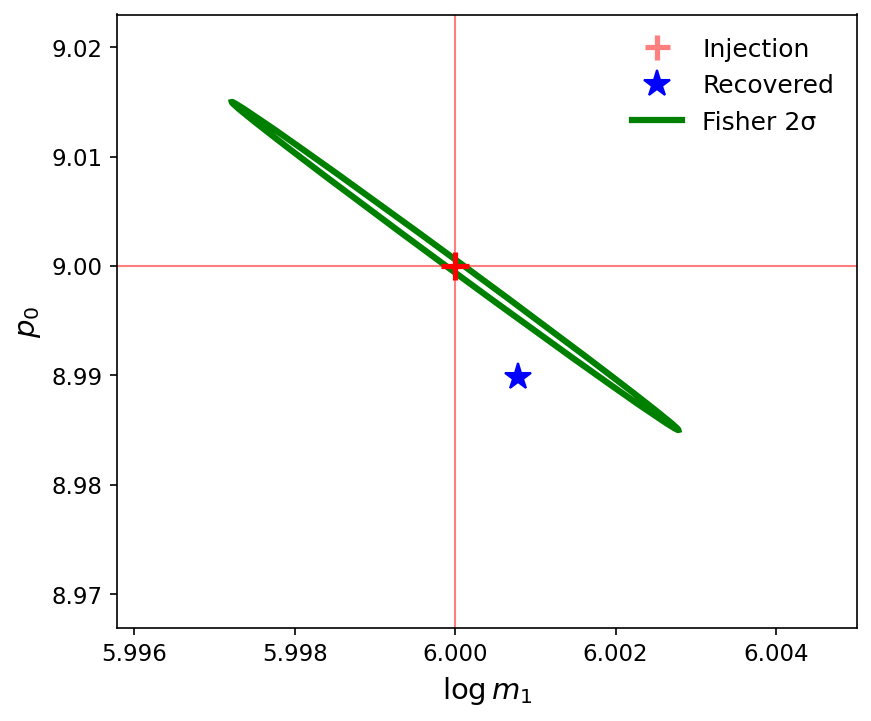

In [16]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

with open('/home/svu/e1498138/emri_search/work/search/cov_matrix_snr30_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                width=2 * n_sigma * np.sqrt(vals[0]),
                height=2 * n_sigma * np.sqrt(vals[1]),
                angle=angle, **kwargs)
    ax.add_patch(ell)

_pt  = np.asarray(param_true).ravel()
_map = np.asarray(maxld_pt1).ravel()
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

ax.set_xlabel(r'$\log m_1$')
ax.set_ylabel(r'$p_0$')
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

xlo = min(_pt[j], _map[j]);  xhi = max(_pt[j], _map[j])
ylo = min(_pt[i], _map[i]);  yhi = max(_pt[i], _map[i])
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=3, zorder=2)

ax.set_xlabel(r'$\log  m_1$')
ax.set_ylabel(r'$p_0$')

legend_handles = [
    Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
    Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,           label='Recovered'),
    Line2D([0], [0], color='green', ls='-',  lw=3,                      label='Fisher 2σ'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

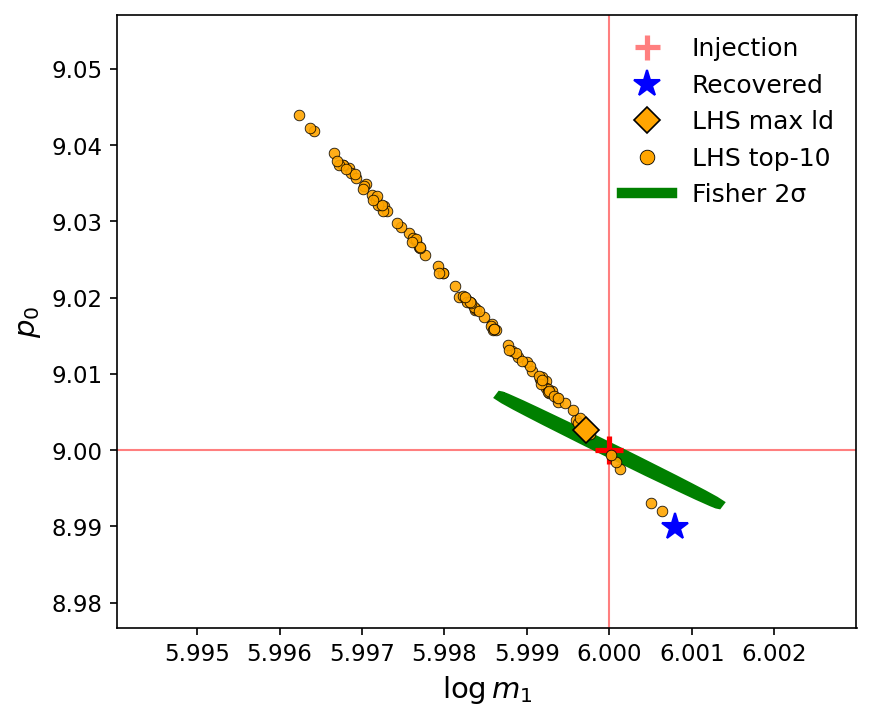

In [17]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

with open('/home/svu/e1498138/emri_search/work/search/cov_matrix_noise_1yr.pkl', 'rb') as f:
    cov = pickle.load(f)

# LHS samples: top-10 by log-density
with open('/scratch/e1498138/paris5_noise/lhs_f.pkl', 'rb') as f:
    lhs = pickle.load(f)
topp     = lhs['lhs_phys'][np.argsort(lhs['log_densities'])[::-1][:100]]  # (10, 5)
lhs_maxld = topp[0]                                                       # best point

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                width=2 * n_sigma * np.sqrt(vals[0]),
                height=2 * n_sigma * np.sqrt(vals[1]),
                angle=angle, **kwargs)
    ax.add_patch(ell)

_pt   = np.asarray(param_true).ravel()
_map  = np.asarray(maxld_pt1).ravel()
_lhs  = np.asarray(lhs_maxld).ravel()
sigs = np.sqrt(np.diag(cov))

j, i = 0, 3   # x = log10(m1), y = p0
cov2d = cov[np.ix_([j, i], [j, i])]

# include all top-10 points in the axis range
xs = np.concatenate([[_pt[j], _map[j]], topp[:, j]])
ys = np.concatenate([[_pt[i], _map[i]], topp[:, i]])
xlo, xhi = xs.min(), xs.max()
ylo, yhi = ys.min(), ys.max()
xpad = (xhi - xlo) * 0.05 + 3 * sigs[j]
ypad = (yhi - ylo) * 0.05 + 3 * sigs[i]

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_xlim(xlo - xpad, xhi + xpad)
ax.set_ylim(ylo - ypad, yhi + ypad)

ax.axvline(_pt[j], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.axhline(_pt[i], color='red', lw=1.0, alpha=0.5, zorder=1)
ax.plot(_pt[j], _pt[i], '+', color='red', ms=13, mew=2.5, zorder=3)
ax.plot(_map[j], _map[i], '*', color='blue', ms=13, zorder=4)

# top-10 LHS points: dots for 2..10, diamond for the best
ax.scatter(topp[1:, j], topp[1:, i], s=26, color='orange',
        edgecolor='black', linewidth=0.4, alpha=0.9, zorder=4)
ax.plot(_lhs[j], _lhs[i], 'D', color='orange', ms=9,
        mec='black', mew=0.8, zorder=5)

draw_cov_ellipse(ax, _pt[j], _pt[i], cov2d,
                n_sigma=2, facecolor='none', edgecolor='green', lw=5, zorder=2)

ax.set_xlabel(r'$\log m_1$')
ax.set_ylabel(r'$p_0$')

legend_handles = [
    Line2D([0], [0], color='red',    marker='+', ls='', ms=12, mew=2.5, alpha=0.5, label='Injection'),
    Line2D([0], [0], color='blue',   marker='*', ls='', ms=13,           label='Recovered'),
    Line2D([0], [0], color='orange', marker='D', ls='', ms=9, mec='black', mew=0.8, label='LHS max ld'),
    Line2D([0], [0], color='orange', marker='o', ls='', ms=7, mec='black', mew=0.4, label='LHS top-10'),
    Line2D([0], [0], color='green',  ls='-',  lw=5,                      label='Fisher 2σ'),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
log_density(topp[0].reshape(1,-1))

array([25.25499768])

In [20]:
log_density(maxld_pt1.reshape(1,-1))

array([25.33197055])

In [22]:
log_density(param_true.reshape(1,-1))

array([24.83302504])

# connection plot

In [19]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1,-1)
proc1_maxld_pt

array([[6.00079056, 1.00019268, 0.70176562, 8.98989313, 0.39980155]])

In [20]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [21]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [22]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [23]:
logden_theory_proc1

array([24.90779643, 24.90789813, 24.90714825, 24.90567016, 24.90360392,
       24.90103521, 24.89809005, 24.89485263, 24.89141282, 24.88783669,
       24.88422747, 24.88061611, 24.87706833, 24.87363862, 24.8703584 ,
       24.86726608, 24.86440082, 24.86177503, 24.85941239, 24.85732376,
       24.8555172 , 24.85400391, 24.85277547, 24.8518309 , 24.85116408,
       24.8507506 , 24.85059081, 24.85066298, 24.85094009, 24.85140445,
       24.85203078, 24.8527917 , 24.85365641, 24.85459618, 24.85557307,
       24.85655726, 24.85751582, 24.85840393, 24.85918501, 24.85981406,
       24.8602491 , 24.86043991, 24.86033674, 24.85988409, 24.8590168 ,
       24.85767318, 24.85576865, 24.85322279, 24.8499589 , 24.84584697])

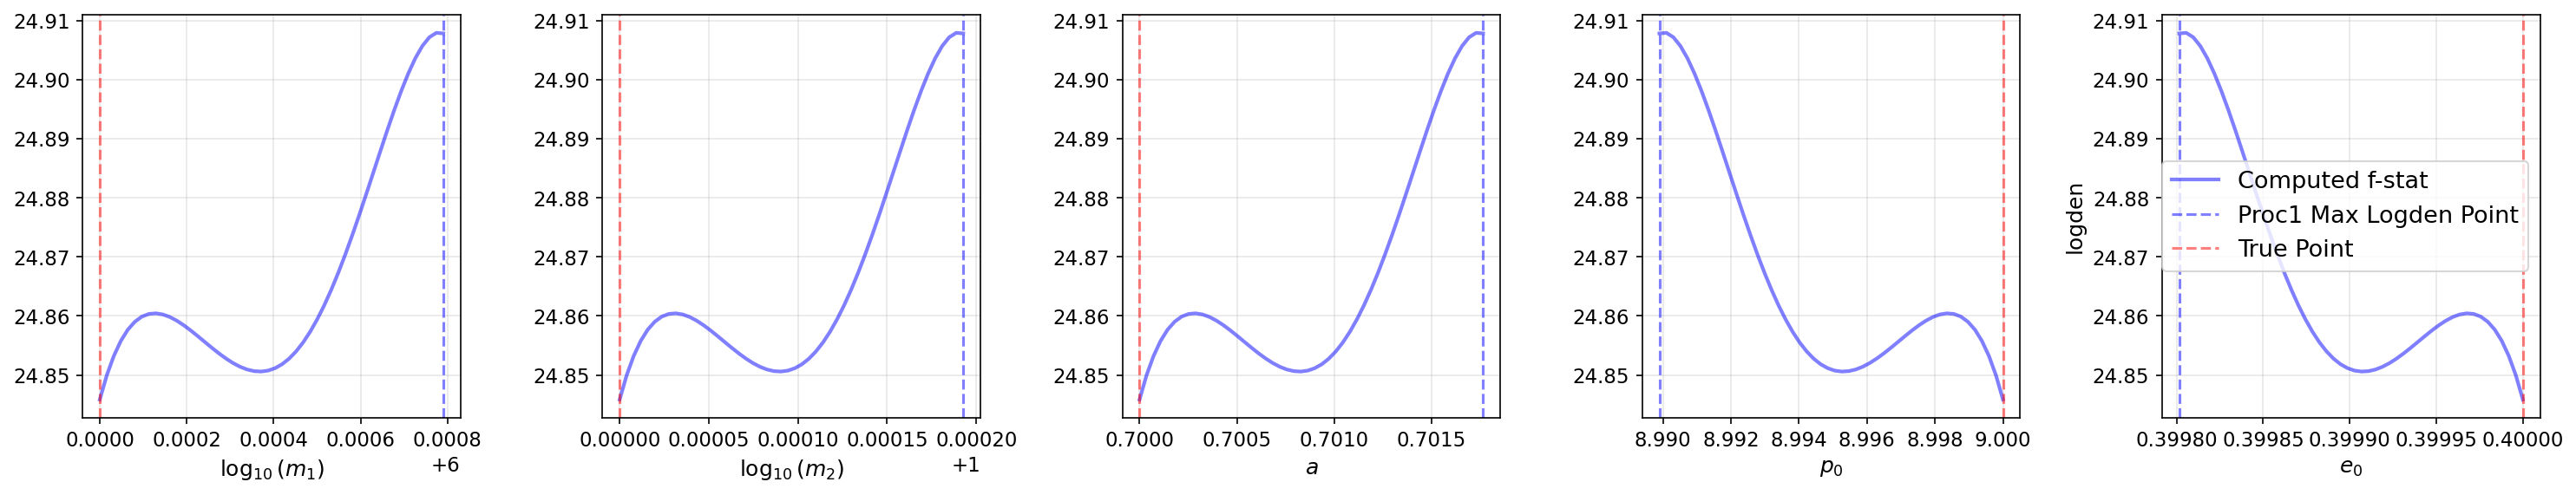

In [24]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
